In [5]:
!pip install scikit-learn scikit-image imbalanced-learn opencv-python

In [6]:
# Importing Libraries
import os
import cv2
import numpy as np
import pandas as pd

from skimage.feature import graycomatrix, graycoprops

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
# Loading Datasets
parkinson_dir = r"C:\Users\user\Desktop\camera\parkinsons_dataset\parkinson"
healthy_dir = r"C:\Users\user\Desktop\camera\parkinsons_dataset\normal"

In [8]:
# Feature Extraction
def extract_features(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128, 128))

    features = []

    # Intensity Features
    features.append(np.mean(img))
    features.append(np.std(img))
    features.append(np.min(img))
    features.append(np.max(img))

    # Texture Features (GLCM)
    glcm = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    features.append(graycoprops(glcm, 'contrast')[0, 0])
    features.append(graycoprops(glcm, 'correlation')[0, 0])
    features.append(graycoprops(glcm, 'energy')[0, 0])
    features.append(graycoprops(glcm, 'homogeneity')[0, 0])

    # Edge Features
    edges = cv2.Canny(img, 100, 200)
    features.append(np.mean(edges))

    return features

In [9]:
data = []
labels = []

# Parkinson’s = 1
for file in os.listdir(parkinson_dir):
    path = os.path.join(parkinson_dir, file)
    feats = extract_features(path)
    data.append(feats)
    labels.append(1)

# Healthy = 0
for file in os.listdir(healthy_dir):
    path = os.path.join(healthy_dir, file)
    feats = extract_features(path)
    data.append(feats)
    labels.append(0)

X = np.array(data)
y = np.array(labels)

print("Shape:", X.shape)

Shape: (831, 9)


In [10]:
# Training, Testing and Splitting 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# Handling class imbalances in the dataset
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
# Training Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [14]:
# Training SVM
svm = SVC(probability=True)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:, 1]

In [15]:
print("Random Forest:\n", classification_report(y_test, y_pred_rf))
print("SVM:\n", classification_report(y_test, y_pred_svm))

Random Forest:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98       123
           1       0.92      1.00      0.96        44

    accuracy                           0.98       167
   macro avg       0.96      0.98      0.97       167
weighted avg       0.98      0.98      0.98       167

SVM:
               precision    recall  f1-score   support

           0       0.98      0.95      0.97       123
           1       0.88      0.95      0.91        44

    accuracy                           0.95       167
   macro avg       0.93      0.95      0.94       167
weighted avg       0.95      0.95      0.95       167



In [16]:
print("RF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

RF Confusion Matrix:
 [[119   4]
 [  0  44]]
SVM Confusion Matrix:
 [[117   6]
 [  2  42]]


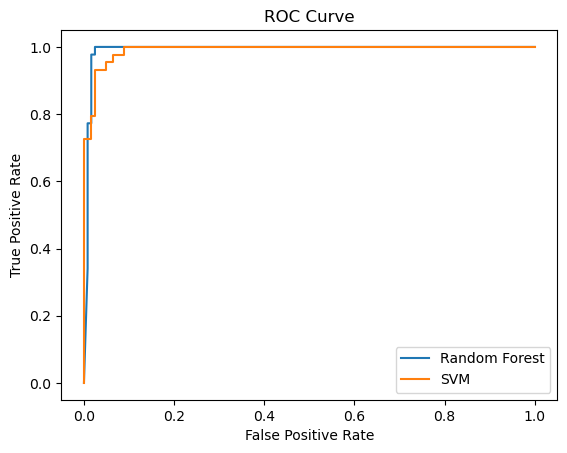

In [17]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_svm, tpr_svm, label="SVM")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [18]:
print("RF AUC:", roc_auc_score(y_test, y_prob_rf))
print("SVM AUC:", roc_auc_score(y_test, y_prob_svm))

RF AUC: 0.9912232076866223
SVM AUC: 0.9909460458240946
